# GPU Architecture Deep Dive: Cores, Memory, and Why Decode is Memory-Bound

This notebook provides a hardware-level explanation of GPU architecture and **why autoregressive decode is bottlenecked by memory bandwidth**, not compute. We start with the different types of cores, then walk through HBM architecture, the roofline model, and show with precise arithmetic why a GPU generating tokens at batch=1 spends most of its time waiting for data.

**Prerequisites**: You understand matrix multiplication and have read notebook 03 (GPU Fundamentals).

**Outline**:
1. GPU core types — CUDA cores, Tensor cores, and the SM hierarchy
2. HBM architecture — what physically sits next to the GPU die
3. The memory wall — arithmetic proof that decode is memory-bound
4. The roofline model — a visual framework for bottleneck analysis
5. Why we never hit peak bandwidth in practice
6. How quantisation helps at the hardware level
7. SRAM vs HBM — on-chip memory and FlashAttention
8. Practical numbers — minimum token latency for a 7B model

## 1. GPU Core Types — What Actually Does the Math

A modern GPU (like NVIDIA's H100) contains thousands of processing units organised into a hierarchy. Understanding which cores do what is critical for knowing where your inference time goes.

### The hierarchy: GPU → GPC → TPC → SM → Cores

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  H100 GPU (full chip)                                                       │
│                                                                             │
│  ┌───────────────────────────────────────────────────────────────────────┐  │
│  │  GPC (Graphics Processing Cluster) × 8                                │  │
│  │                                                                       │  │
│  │  ┌─────────────────────────────────────────────────────────────────┐  │  │
│  │  │  TPC (Texture Processing Cluster) × 2 per GPC                   │  │  │
│  │  │                                                                 │  │  │
│  │  │  ┌───────────────────────────────────────────────────────────┐  │  │  │
│  │  │  │  SM (Streaming Multiprocessor) × 132 total                │  │  │  │
│  │  │  │                                                           │  │  │  │
│  │  │  │  • 128 CUDA (FP32) cores                                 │  │  │  │
│  │  │  │  • 4 Tensor cores (4th gen)                               │  │  │  │
│  │  │  │  • 64 INT32 cores                                         │  │  │  │
│  │  │  │  • 16 Special function units (SFU)                        │  │  │  │
│  │  │  │  • 4 Texture units                                        │  │  │  │
│  │  │  │  • 228 KB shared memory / L1 cache                        │  │  │  │
│  │  │  │  • 256 KB register file                                   │  │  │  │
│  │  │  │  • Warp schedulers (4 per SM)                              │  │  │  │
│  │  │  └───────────────────────────────────────────────────────────┘  │  │  │
│  │  └─────────────────────────────────────────────────────────────────┘  │  │
│  └───────────────────────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────────────┘
```

### The three core types that matter for LLMs

#### CUDA Cores (FP32/FP64)
- **What they do**: General-purpose floating point arithmetic. One operation per core per clock.
- **Count**: 16,896 on H100 (128 per SM × 132 SMs)
- **Peak throughput**: ~67 TFLOPS FP32, ~34 TFLOPS FP64
- **Used for**: Element-wise ops (GeLU, LayerNorm, residual add), dequantisation, softmax, sampling
- **Think of them as**: Individual workers each doing one add or multiply per clock tick

```
CUDA core operation (1 clock cycle):
    result = a * b + c     ← one FMA (fused multiply-add)
    
That's it. One number in, one number out, per cycle, per core.
16,896 cores × 2 GHz × 2 ops/FMA = ~67 TFLOPS
```

#### Tensor Cores (the matmul engines)
- **What they do**: Matrix multiply-accumulate on small tiles (e.g. 16×16×16)
- **Count**: 528 on H100 (4 per SM × 132 SMs)
- **Peak throughput**: ~990 TFLOPS FP16 (with sparsity), ~495 TFLOPS dense
- **Used for**: ALL matmuls (attention projections Q/K/V/O, MLP layers, lm_head)
- **Think of them as**: Dedicated matrix multiplication factories

```
Tensor core operation (1 clock cycle):
    C[16×16] += A[16×16] × B[16×16]    ← 4096 FMA operations in one shot!

One tensor core does in 1 cycle what 4096 CUDA cores do in 1 cycle.
That's why they're 7-8x faster for matmuls.
```

**Key**: Tensor cores can ONLY do matrix multiplication. They cannot do softmax, GeLU, or any other operation. If your workload isn't a matmul, tensor cores sit idle.

#### RT Cores (Ray Tracing)
- **What they do**: BVH traversal and ray-triangle intersection
- **Count**: 132 on H100 (1 per SM)
- **Used for**: Graphics rendering (ray tracing)
- **Used for LLMs**: **Never.** Completely irrelevant for inference.

### Why this matters for LLM inference

LLM forward passes are **~95% matrix multiplications** (attention projections + MLP layers). This means tensor cores do almost all the useful work:

```
Operation breakdown in a typical LLM forward pass:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Attention Q/K/V projections  │████████████│  ~25%  → Tensor cores
  Attention score (Q @ K^T)    │████████████│  ~20%  → Tensor cores
  Attention output (attn @ V)  │████████████│  ~15%  → Tensor cores
  Attention O projection       │████████    │  ~10%  → Tensor cores
  MLP gate + up projection     │████████████│  ~15%  → Tensor cores
  MLP down projection          │████████    │  ~10%  → Tensor cores
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        Subtotal tensor cores:  ~95%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LayerNorm / RMSNorm          │█           │  ~1%   → CUDA cores
  GeLU / SiLU activation       │█           │  ~1%   → CUDA cores
  Softmax                      │█           │  ~1%   → CUDA cores
  Residual connections         │            │  <1%   → CUDA cores
  Sampling (argmax/top-k)      │            │  <1%   → CUDA cores
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        Subtotal CUDA cores:    ~5%
```

### The precision story across core types

| Core type | Supported precisions | Peak on H100 |
|-----------|---------------------|--------------|
| Tensor cores | FP64, TF32, FP16, BF16, FP8, INT8 | 495-990 TFLOPS |
| CUDA cores | FP64, FP32 | 34-67 TFLOPS |

Tensor cores get **faster** at lower precision because more elements fit in the same 16×16 tile:
- FP16: 4096 ops per tile per cycle
- FP8: 8192 ops per tile per cycle (2x FP16)
- INT8: 8192 ops per tile per cycle

This is another reason quantisation helps: not only fewer bytes to load, but tensor cores process more elements per cycle at INT8/FP8.

### Warps and occupancy — how work gets scheduled

A **warp** = 32 threads executing the same instruction in lockstep (SIMT model).

Each SM has 4 warp schedulers that can issue instructions to warps every cycle. When one warp stalls (waiting for memory), the scheduler instantly switches to another ready warp — **hiding latency through parallelism**.

```
Warp 0: compute... compute... STALL (waiting for memory)
Warp 1: ───────────────────── execute ────── STALL
Warp 2: ──────────────────────────────────── execute ────── STALL
Warp 3: ─────────────────────────────────────────────────── execute

The SM is never idle as long as there are ready warps.
This is why GPUs need THOUSANDS of threads — to hide memory latency.
```

**Occupancy** = fraction of maximum warps that are active on an SM. Higher occupancy = more warps available to hide memory latency. LLM inference at batch=1 often has LOW occupancy (not enough work to fill all warp slots), which makes the memory-bound problem even worse.

## 2. HBM Architecture — What Physically Sits Next to the GPU

**HBM (High Bandwidth Memory)** is not just "fast DRAM." It is a fundamentally different physical arrangement designed to solve the memory wall problem.

### Physical structure

HBM uses **3D stacking** — multiple DRAM dies are stacked vertically and connected by thousands of through-silicon vias (TSVs). Each stack sits on a silicon interposer directly adjacent to the GPU die, connected by very short (~100um) traces.

```
        Traditional (GDDR6)                    HBM
    ┌─────────────────────────┐        ┌──────────────────────────┐
    │                         │        │                          │
    │   GPU die               │        │  ┌───┐ ┌───┐ ┌───┐     │
    │         ═══════════╗    │        │  │ S │ │ S │ │ S │ GPU  │
    │                    ║    │        │  │ t │ │ t │ │ t │ die  │
    │                    ║    │        │  │ a │ │ a │ │ a │      │
    │         ════PCB════╝    │        │  │ c │ │ c │ │ c │      │
    │              traces     │        │  │ k │ │ k │ │ k │      │
    │              (~cm)      │        │  │ 1 │ │ 2 │ │ 3 │      │
    │                         │        │  └─┬─┘ └─┬─┘ └─┬─┘      │
    │   DRAM chips (spread    │        │    └──┴──┴──┘            │
    │    around the PCB)      │        │     silicon interposer    │
    └─────────────────────────┘        └──────────────────────────┘
    
    Bus width: 32 bits per chip         Bus width: 1024 bits per stack
    Distance: centimetres               Distance: ~100 micrometres
```

### Why stacking gives bandwidth

Bandwidth = bus_width × clock_speed. HBM wins on bus width:

| | GDDR6X (RTX 4090) | HBM2e (A100) | HBM3 (H100) | HBM3e (MI300X) |
|---|---|---|---|---|
| Stacks | N/A (flat chips) | 5 stacks | 5 stacks | 8 stacks |
| Layers per stack | 1 | 8 | 8 | 8 |
| Bus width per stack | 32 bits | 1024 bits | 1024 bits | 1024 bits |
| Total bus width | 384 bits | 5120 bits | 5120 bits | 8192 bits |
| Clock speed | 1313 MHz | 1600 MHz | 2000 MHz | 1600 MHz |
| **Bandwidth** | **1.01 TB/s** | **2.0 TB/s** | **3.35 TB/s** | **5.3 TB/s** |
| Capacity | 24 GB | 80 GB | 80 GB | 192 GB |

**Key insight**: HBM achieves bandwidth through massive parallelism (thousands of data pins via TSVs), not by clocking faster. Each individual channel is slower than GDDR6X, but there are vastly more of them operating simultaneously.

### Channels and pseudo-channels

Each HBM stack exposes **2 pseudo-channels** of 64 bytes each. The A100's 5 stacks provide 10 independent 64-byte channels that the memory controller can access concurrently. This means:
- Maximum single-access granularity: 64 bytes (one cache line from one pseudo-channel)
- Peak throughput requires all channels active simultaneously
- Sequential access patterns that hit a single channel get only ~1/10th of peak bandwidth

## 3. The Memory Wall — Arithmetic Proof That Decode is Memory-Bound

Let's work through a concrete example. Consider a single linear layer during decode at batch=1.

### Setup

- Weight matrix: `[2048, 6144]` (a typical MLP up-projection in a ~2B model)
- Input vector: `[1, 2048]` (one token's hidden state)
- Precision: FP16 (2 bytes per element)
- GPU: H100 SXM (3.35 TB/s bandwidth, 990 TFLOPS FP16 with sparsity, ~495 TFLOPS dense)

### Step 1: How many bytes must we load?

```
Weight matrix:  2048 x 6144 x 2 bytes = 25,165,824 bytes = 25.17 MB
Input vector:   1 x 2048 x 2 bytes    = 4,096 bytes       = 0.004 MB
                                                    Total  ~ 25.17 MB
```

The input is negligible. We must stream **25.17 MB** from HBM.

### Step 2: How long does the memory load take?

```
Time_memory = bytes / bandwidth
            = 25.17 MB / 3,350,000 MB/s
            = 7.51 microseconds
```

### Step 3: How many FLOPs does this matmul produce?

For a matrix-vector multiply `[1, 2048] x [2048, 6144]`:
```
FLOPs = 2 x M x N x K  (multiply-accumulate = 2 ops)
      = 2 x 1 x 6144 x 2048
      = 25,165,824 FLOPs
      ~ 25.17 MFLOPs
```

### Step 4: How long would the compute take?

```
Time_compute = FLOPs / compute_throughput
             = 25.17 MFLOPs / 495,000,000 MFLOPs/s  (495 TFLOPS dense)
             = 0.051 microseconds
```

### Step 5: The ratio tells the story

```
Time_memory / Time_compute = 7.51 / 0.051 = 147x

The GPU finishes the math 147x faster than it can load the data.
```

**The compute units are idle 99.3% of the time**, waiting for the next chunk of weights to arrive from HBM. This is what "memory-bound" means in practice — those 528 tensor cores are sitting there doing nothing, starved for data.

### Why batch=1 is the worst case

The weight matrix must be loaded regardless of batch size. But the FLOPs scale linearly with batch:

| Batch size | Bytes loaded | FLOPs | Arithmetic Intensity | Memory time | Compute time | Bound by |
|---|---|---|---|---|---|---|
| 1 | 25.17 MB | 25.2 M | 1.0 FLOP/byte | 7.51 us | 0.051 us | Memory |
| 32 | 25.30 MB | 805 M | 31.8 FLOP/byte | 7.55 us | 1.63 us | Memory |
| 128 | 25.67 MB | 3,221 M | 125.5 FLOP/byte | 7.66 us | 6.51 us | Memory |
| 256 | 26.17 MB | 6,442 M | 246 FLOP/byte | 7.81 us | 13.0 us | Balanced |
| 512 | 27.17 MB | 12,885 M | 474 FLOP/byte | 8.11 us | 26.0 us | Compute |

The crossover (where memory time = compute time) happens around batch ~250 on H100. Below that, you are memory-bound and the tensor cores sit partially idle.

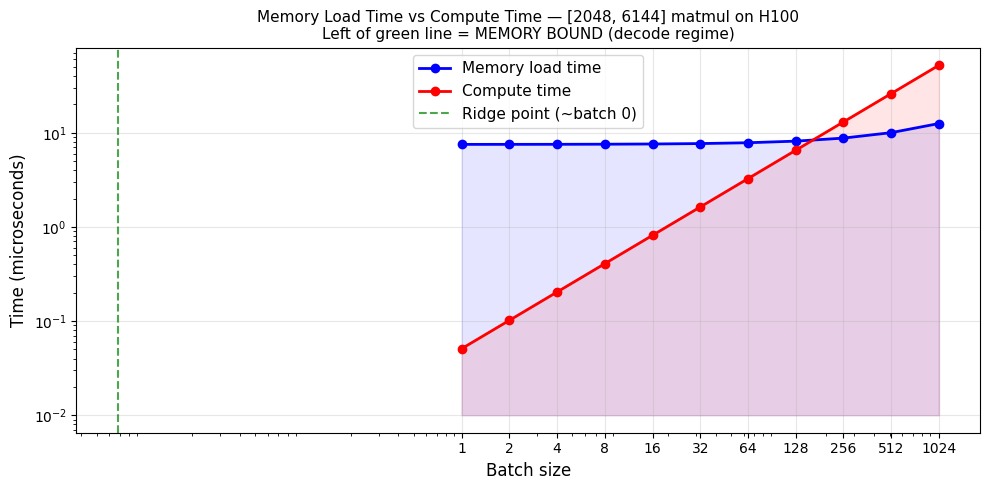

Ridge point (crossover): batch size ~ 0
At batch=1: memory takes 7.52 us, compute takes 0.051 us
  -> GPU compute utilisation: 0.7%
At batch=256: memory takes 8.76 us, compute takes 13.02 us
  -> Approaching balanced regime


In [1]:
# Visualise the memory-bound vs compute-bound crossover
import numpy as np
import matplotlib.pyplot as plt

# H100 specs
bandwidth_TB_s = 3.35       # TB/s
compute_TFLOPS = 495        # TFLOPS (dense FP16, not sparsity)
bandwidth_B_s = bandwidth_TB_s * 1e12
compute_FLOPS = compute_TFLOPS * 1e12

# Weight matrix: [2048, 6144] in FP16
M, K, N = 1, 2048, 6144  # batch=1 means M=1
weight_bytes = K * N * 2  # FP16

batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024])

memory_times = []
compute_times = []

for bs in batch_sizes:
    # Bytes: weight + input + output
    total_bytes = weight_bytes + bs * K * 2 + bs * N * 2
    flops = 2 * bs * K * N
    
    t_mem = total_bytes / bandwidth_B_s * 1e6  # microseconds
    t_comp = flops / compute_FLOPS * 1e6       # microseconds
    
    memory_times.append(t_mem)
    compute_times.append(t_comp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(batch_sizes, memory_times, 'b-o', linewidth=2, label='Memory load time')
ax.loglog(batch_sizes, compute_times, 'r-o', linewidth=2, label='Compute time')
ax.fill_between(batch_sizes, 0.01, memory_times, alpha=0.1, color='blue')
ax.fill_between(batch_sizes, 0.01, compute_times, alpha=0.1, color='red')

# Find crossover
crossover_batch = weight_bytes / (compute_FLOPS / bandwidth_B_s * 2 * K * N - 2 * (K + N))
ax.axvline(x=crossover_batch, color='green', linestyle='--', alpha=0.7, 
           label=f'Ridge point (~batch {crossover_batch:.0f})')

ax.set_xlabel('Batch size', fontsize=12)
ax.set_ylabel('Time (microseconds)', fontsize=12)
ax.set_title('Memory Load Time vs Compute Time — [2048, 6144] matmul on H100\n'
             'Left of green line = MEMORY BOUND (decode regime)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(batch_sizes)
ax.set_xticklabels(batch_sizes)
plt.tight_layout()
plt.show()

print(f"Ridge point (crossover): batch size ~ {crossover_batch:.0f}")
print(f"At batch=1: memory takes {memory_times[0]:.2f} us, compute takes {compute_times[0]:.3f} us")
print(f"  -> GPU compute utilisation: {compute_times[0]/memory_times[0]*100:.1f}%")
print(f"At batch=256: memory takes {memory_times[8]:.2f} us, compute takes {compute_times[8]:.2f} us")
print(f"  -> Approaching balanced regime")

## 4. The Roofline Model

The roofline model plots achievable performance (FLOPS) as a function of **arithmetic intensity** (FLOPs per byte of memory traffic). It has two regimes separated by a "ridge point":

```
Performance (TFLOPS)
    ▲
    │                          ┌─────────────── Peak Compute (495 TFLOPS)
    │                         /│
    │                        / │
    │                       /  │  COMPUTE-BOUND
    │                      /   │  (prefill, large batch)
    │                     /    │
    │                    /     │
    │                   /      │
    │                  /       │
    │  MEMORY-BOUND   /        │
    │  (decode b=1)  /         │
    │               /          │
    │              /           │
    │             /            │
    │            / slope = peak bandwidth (3.35 TB/s for H100)
    │           /              │
    │          /               │
    └─────────┼────────────────┼─────────────────────────► Arithmetic Intensity
              │                │                            (FLOPs / byte)
              │          Ridge Point
              │
              
    Ridge point = Peak Compute / Peak Bandwidth
```

### Ridge points for modern GPUs

| GPU | Peak FP16 (dense) | HBM Bandwidth | Ridge Point |
|---|---|---|---|
| A100 SXM | 312 TFLOPS | 2.0 TB/s | **156 FLOPs/byte** |
| H100 SXM | 495 TFLOPS | 3.35 TB/s | **148 FLOPs/byte** |
| MI300X | 383 TFLOPS | 5.3 TB/s | **72 FLOPs/byte** |

**Interpretation**: If your kernel performs fewer than ~148 FLOPs per byte loaded (on H100), you are memory-bound. The GPU computes so fast that it exhausts available data almost instantly and then stalls.

### Where LLM operations land on the roofline

| Operation | Arithmetic Intensity | Regime |
|---|---|---|
| Decode matmul, batch=1 | ~1 FLOP/byte | Deep memory-bound |
| Decode matmul, batch=32 | ~32 FLOPs/byte | Memory-bound |
| Decode matmul, batch=256 | ~246 FLOPs/byte | Compute-bound |
| Prefill matmul, seq=2048 | ~2048 FLOPs/byte | Deep compute-bound |
| Softmax | ~0.25 FLOPs/byte | Extremely memory-bound |
| LayerNorm | ~5 FLOPs/byte | Memory-bound |
| Element-wise (GeLU) | ~1 FLOP/byte | Memory-bound |

Most non-matmul operations (norms, activations, reductions) are permanently memory-bound regardless of batch size because they do O(1) work per element loaded. These are the operations that run on CUDA cores — and they're memory-bound not because CUDA cores are slow, but because there's simply not enough math to do per byte loaded.

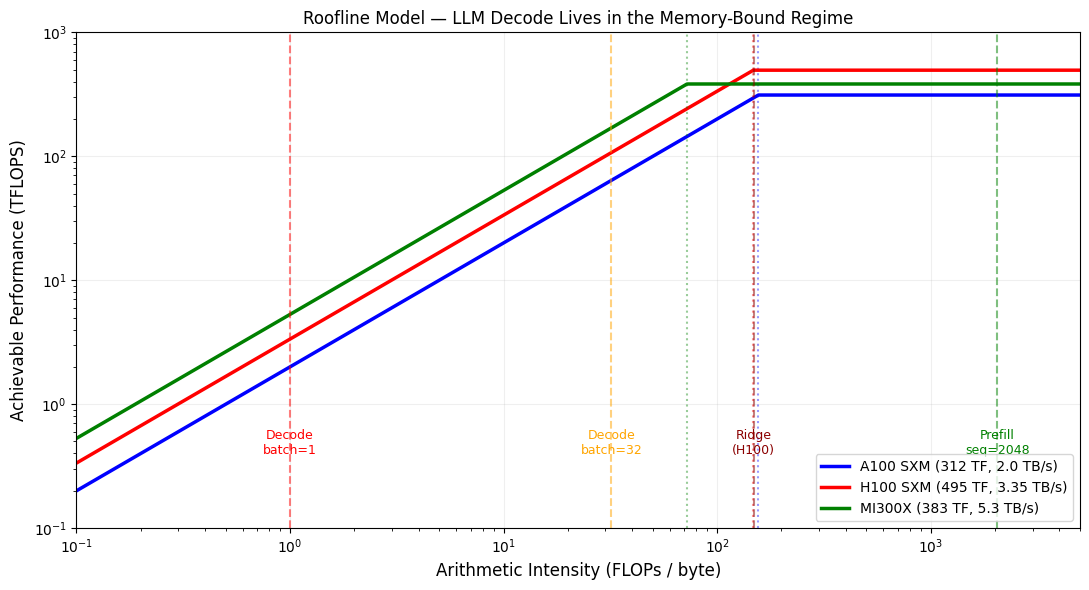

At batch=1 decode (AI=1 FLOP/byte), H100 achieves ~3.35 TFLOPS out of 495 TFLOPS peak.
That's 0.7% compute utilisation — the rest is waiting for memory.


In [2]:
# Roofline model visualisation
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))

# GPU specs: (name, peak_TFLOPS, bandwidth_TB_s, color)
gpus = [
    ("A100 SXM (312 TF, 2.0 TB/s)", 312, 2.0, "blue"),
    ("H100 SXM (495 TF, 3.35 TB/s)", 495, 3.35, "red"),
    ("MI300X (383 TF, 5.3 TB/s)", 383, 5.3, "green"),
]

x = np.logspace(-1, 4, 1000)  # arithmetic intensity (FLOPs/byte)

for name, peak_tf, bw_tb, color in gpus:
    peak_flops = peak_tf  # in TFLOPS for y-axis
    bw = bw_tb * 1e12 / 1e12  # TB/s -> TFLOPS per FLOP/byte (= TB/s numerically)
    
    # Roofline: min(peak, bandwidth * arithmetic_intensity)
    achievable = np.minimum(peak_flops, bw * x)
    ax.loglog(x, achievable, linewidth=2.5, color=color, label=name)
    
    # Ridge point
    ridge = peak_flops / (bw_tb)  # FLOPs per byte
    ax.axvline(x=ridge, color=color, linestyle=':', alpha=0.4)

# Mark LLM operations
operations = [
    (1.0, "Decode\nbatch=1", "red"),
    (32, "Decode\nbatch=32", "orange"),
    (148, "Ridge\n(H100)", "darkred"),
    (2048, "Prefill\nseq=2048", "green"),
]

for intensity, label, color in operations:
    ax.axvline(x=intensity, color=color, linestyle='--', alpha=0.5)
    ax.text(intensity, 0.15, label, ha='center', fontsize=9, color=color,
            transform=ax.get_xaxis_transform())

ax.set_xlabel('Arithmetic Intensity (FLOPs / byte)', fontsize=12)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=12)
ax.set_title('Roofline Model — LLM Decode Lives in the Memory-Bound Regime', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.2)
ax.set_xlim(0.1, 5000)
ax.set_ylim(0.1, 1000)
plt.tight_layout()
plt.show()

print("At batch=1 decode (AI=1 FLOP/byte), H100 achieves ~3.35 TFLOPS out of 495 TFLOPS peak.")
print(f"That's {3.35/495*100:.1f}% compute utilisation — the rest is waiting for memory.")

## 5. Why We Never Achieve Peak Bandwidth in Practice

The numbers above use **theoretical peak** bandwidth (3.35 TB/s for H100). Real workloads typically achieve 70-85% of peak. Here's why:

### Memory access inefficiencies

**1. Bank conflicts**
HBM is organized into banks. When multiple memory requests map to the same bank, they serialize rather than execute in parallel. For LLM weight loads this is rarely an issue (large sequential reads), but for scattered KV cache access patterns it matters.

**2. Alignment requirements**
Memory transactions happen in fixed-size chunks (typically 32 or 128 bytes). If your data isn't aligned to transaction boundaries, you load extra bytes that are discarded. A weight matrix row of 2048 FP16 elements = 4096 bytes is naturally aligned, but irregular tensor shapes or padding can cause waste.

**3. TLB (Translation Lookaside Buffer) misses**
GPUs use virtual memory with page tables. The TLB caches virtual-to-physical address translations. When accessing scattered memory regions (e.g., non-contiguous KV cache pages in PagedAttention), TLB misses force the memory controller to walk page tables, adding ~100-200 ns per miss.

**4. Refresh cycles**
DRAM (including HBM) must periodically refresh all cells to prevent data decay. During refresh, the affected bank is unavailable. This steals ~5-10% of effective bandwidth.

**5. Memory controller queuing**
The memory controller has finite queue depth. When many SMs issue memory requests simultaneously, some requests queue. Under high contention, effective bandwidth drops as requests wait in line.

### Practical bandwidth numbers

| Scenario | % of peak | Effective BW (H100) |
|---|---|---|
| Large sequential read (ideal) | 85-92% | 2.85-3.08 TB/s |
| Model weight streaming (typical LLM) | 75-85% | 2.51-2.85 TB/s |
| KV cache random access | 50-70% | 1.68-2.35 TB/s |
| Small scattered reads | 30-50% | 1.00-1.68 TB/s |

**For back-of-envelope latency calculations, use 80% of peak bandwidth.** This gives conservative but realistic estimates for weight-streaming workloads.

## 6. How Quantisation Helps — At the Hardware Level

We know decode is memory-bound. The GPU spends most of its time waiting for weight bytes to arrive from HBM. Quantisation reduces the number of bytes per weight, directly reducing this wait time.

### What physically happens when weights go from FP16 to INT4

**FP16 (baseline):**
```
Each weight: 16 bits (2 bytes)
Weight matrix [2048, 6144]: 25.17 MB
HBM → SM transfer time (H100): 7.51 us
```

**INT4 (quantised):**
```
Each weight: 4 bits (0.5 bytes)
Weight matrix [2048, 6144]: 6.29 MB  (+ ~0.2 MB for group scales at g=128)
HBM → SM transfer time (H100): 1.94 us
```

That's a **3.9x reduction in load time** — which directly translates to ~3.9x faster decode (since we're memory-bound and the load dominates).

### The data path in detail

```
FP16 path:
  HBM stacks ──[5120-bit bus]──→ L2 cache ──→ SM shared memory ──→ Tensor cores
                                                                      ↓
  25.17 MB streamed                                             matmul output

INT4 path:
  HBM stacks ──[5120-bit bus]──→ L2 cache ──→ SM shared memory ──→ Dequant (CUDA cores) ──→ Tensor cores
                                                                      ↓                          ↓
  6.29 MB streamed                                              INT4→FP16 expand           matmul output
```

### Why dequantisation cost is negligible

The dequantisation operation per element is:
```
fp16_value = (int4_value - zero_point) * scale
```

This is 1 subtract + 1 multiply per weight element — work for CUDA cores. For our `[2048, 6144]` matrix:
- Dequant FLOPs: 2 × 2048 × 6144 = 25.2 MFLOPs
- Time at 67 TFLOPS (CUDA core peak): 0.38 us

Compare to the 1.94 us memory load time — dequantisation adds ~19% overhead in the worst case. In practice it's hidden because CUDA cores dequantise the current tile while memory streams the next tile (pipelining).

On H100 specifically, FP8 dequantisation is handled natively by the tensor cores (zero overhead). INT4/INT8 dequantisation happens in the SM's CUDA cores in parallel with the next memory load, effectively hiding it completely.

### The bandwidth multiplier effect

| Format | Bytes/weight | Model size (7B) | Effective bandwidth multiplier | Decode speedup vs FP16 |
|---|---|---|---|---|
| FP16 | 2.0 | 14 GB | 1.0x | 1.0x |
| INT8 | 1.0 | 7 GB | 2.0x | ~1.9x |
| FP8 | 1.0 | 7 GB | 2.0x | ~2.0x (native on H100) |
| INT4 (g=128) | 0.56 | 3.9 GB | 3.6x | ~3.4x |
| INT4 (g=32) | 0.63 | 4.4 GB | 3.2x | ~3.0x |

The "effective bandwidth multiplier" is the key mental model: **quantisation makes HBM act as if it were faster**, because each byte loaded contains more useful weight information.

## 7. SRAM (Shared Memory) vs HBM — On-Chip Memory

Each SM has a small but extremely fast on-chip memory called **shared memory** (or SRAM). This is the key to understanding why algorithms like FlashAttention are transformative.

### The numbers

| Memory level | H100 capacity | Bandwidth | Latency |
|---|---|---|---|
| Registers | 256 KB per SM (132 SMs) | effectively infinite | 0 cycles |
| Shared memory (SRAM) | 228 KB per SM = ~30 MB total | ~19 TB/s aggregate | ~20-30 cycles |
| L2 cache | 50 MB | ~12 TB/s | ~200 cycles |
| HBM | 80 GB | 3.35 TB/s | ~400-600 cycles |

Shared memory is **5.7x faster** than HBM in bandwidth and **20x lower latency**. But it's 2,600x smaller.

### The FlashAttention insight

Standard attention computes:
```
S = Q @ K^T        # [seq, seq] — huge intermediate stored in HBM
P = softmax(S)     # [seq, seq] — another huge matrix in HBM  
O = P @ V          # [seq, d]   — final output
```

For a 4096-token sequence: `S` and `P` are each 4096 × 4096 × 2 bytes = 32 MB. This data is written to HBM then immediately read back — pure waste.

**FlashAttention** restructures the computation into tiles that fit in shared memory:

```
For each tile of Q (fits in SRAM):
    For each tile of K, V (fits in SRAM):
        Compute partial S = Q_tile @ K_tile^T     ← stays in SRAM (tensor cores)
        Compute partial softmax                    ← stays in SRAM (CUDA cores)
        Accumulate O_tile += softmax_tile @ V_tile ← stays in SRAM (tensor cores)
    Write final O_tile to HBM (once)
```

The key: **S and P never materialise in HBM**. They are computed, used, and discarded entirely within shared memory. This eliminates ~32 MB of HBM reads + 32 MB of HBM writes per attention layer.

### Impact on the memory wall

```
Standard attention memory traffic:  O(seq²) — reads/writes S and P from HBM
FlashAttention memory traffic:      O(seq)  — only reads Q,K,V and writes O

For seq=4096, d=128:
  Standard: ~128 MB HBM traffic per attention layer
  Flash:    ~4 MB HBM traffic per attention layer
  Reduction: 32x less HBM traffic
```

FlashAttention doesn't make the matmuls faster — it eliminates unnecessary round-trips to HBM by keeping intermediate results in the 228 KB of shared memory that sits right next to the compute units. Both CUDA cores (softmax) and tensor cores (matmuls) operate on data already in SRAM — no trips to HBM in between.

## 8. Practical Numbers — Minimum Token Latency for a 7B Model

Let's calculate the theoretical minimum latency per token for a 7B parameter model doing decode at batch=1, based purely on memory bandwidth.

### Model assumptions (LLaMA-2-7B architecture)

```
Parameters:         6.74B (actual, commonly rounded to 7B)
Precision:          FP16 (2 bytes per parameter)
Total weight size:  6.74B x 2 bytes = 13.48 GB
```

### Theoretical minimum — every token requires loading all weights once

During decode, generating **one token** requires a forward pass through all layers. Each weight is used exactly once (for a single matrix-vector multiply on the tensor cores), then never reused until the next token. The weights are too large to cache on-chip (13.48 GB vs ~80 MB of L2+SRAM).

Therefore: **minimum time per token = total weight bytes / memory bandwidth**

| GPU | Bandwidth | Min latency (FP16) | Max tok/s (FP16) |
|---|---|---|---|
| RTX 4090 | 1.01 TB/s | 13.35 ms | 74.9 tok/s |
| A100 SXM | 2.0 TB/s | 6.74 ms | 148 tok/s |
| H100 SXM | 3.35 TB/s | 4.02 ms | 249 tok/s |
| MI300X | 5.3 TB/s | 2.54 ms | 394 tok/s |

### With INT4 quantisation (g=128)

```
Total weight size:  6.74B x 0.5 bytes + scales overhead ≈ 3.9 GB
```

| GPU | Bandwidth | Min latency (INT4) | Max tok/s (INT4) |
|---|---|---|---|
| RTX 4090 | 1.01 TB/s | 3.86 ms | 259 tok/s |
| A100 SXM | 2.0 TB/s | 1.95 ms | 513 tok/s |
| H100 SXM | 3.35 TB/s | 1.16 ms | 862 tok/s |
| MI300X | 5.3 TB/s | 0.74 ms | 1,351 tok/s |

### Comparison to observed real-world latency

Real-world decode adds overhead beyond pure weight streaming:
- KV cache reads (attention keys/values for all previous tokens)
- LayerNorm, activation functions, residual connections (CUDA core work)
- Kernel launch overhead (~5-10 us per kernel × ~100 kernels per layer)
- Memory bandwidth efficiency (~75-85% of peak)
- Sampling (top-k, top-p) and tokenizer decode

| GPU | Model | Theoretical min | Observed (vLLM, batch=1) | Efficiency |
|---|---|---|---|---|
| A100 SXM | LLaMA-2-7B FP16 | 148 tok/s | 95-115 tok/s | 64-78% |
| H100 SXM | LLaMA-2-7B FP16 | 249 tok/s | 160-200 tok/s | 64-80% |
| A100 SXM | LLaMA-2-7B INT4 | 513 tok/s | 320-400 tok/s | 62-78% |
| H100 SXM | LLaMA-2-7B INT4 | 862 tok/s | 550-700 tok/s | 64-81% |

Achieving **65-80% of theoretical maximum** is considered good engineering. The gap comes from the overheads listed above, particularly KV cache reads at long context lengths.

### The fundamental equation of decode performance

```
                    model_bytes
  token_latency >= ─────────────  +  kv_cache_overhead  +  kernel_overhead
                    bandwidth

  This is the floor. You cannot beat it without:
    1. Reducing model_bytes (quantisation — fewer bytes to stream from HBM)
    2. Increasing bandwidth (better hardware, tensor parallelism across GPUs)
    3. Reducing per-token weight loads (speculative decoding — amortise over multiple tokens)
    4. Batching (same weight load, more useful work for tensor cores)
```

This equation is why the LLM inference optimisation landscape exists. Every major technique attacks one of these terms.

In [3]:
# Token latency calculator — play with these numbers
import numpy as np

def decode_latency_calculator(
    params_billions: float = 6.74,
    bytes_per_param: float = 2.0,       # FP16=2.0, INT8=1.0, INT4=0.5
    scale_overhead_frac: float = 0.0,    # e.g. 0.12 for INT4 g=128 (12% extra for scales)
    bandwidth_TB_s: float = 3.35,        # H100 SXM
    bandwidth_efficiency: float = 0.80,  # typical 75-85%
    kv_cache_tokens: int = 512,          # context length so far
    num_layers: int = 32,
    num_kv_heads: int = 32,
    head_dim: int = 128,
    kv_bytes_per_element: float = 2.0,   # FP16 KV cache
):
    """Calculate theoretical decode latency per token."""
    
    # Weight streaming
    model_bytes = params_billions * 1e9 * bytes_per_param * (1 + scale_overhead_frac)
    effective_bw = bandwidth_TB_s * 1e12 * bandwidth_efficiency
    weight_time_ms = model_bytes / effective_bw * 1000
    
    # KV cache read (attention reads all cached K,V for each layer)
    kv_bytes_per_token = 2 * num_layers * num_kv_heads * head_dim * kv_bytes_per_element
    kv_total_bytes = kv_bytes_per_token * kv_cache_tokens
    kv_time_ms = kv_total_bytes / effective_bw * 1000
    
    # Kernel overhead (rough estimate: ~100 kernels per forward pass, ~7us each)
    kernel_overhead_ms = 100 * 7e-6 * 1000
    
    total_ms = weight_time_ms + kv_time_ms + kernel_overhead_ms
    tokens_per_sec = 1000 / total_ms
    
    return {
        "model_size_GB": model_bytes / 1e9,
        "weight_time_ms": weight_time_ms,
        "kv_cache_size_MB": kv_total_bytes / 1e6,
        "kv_time_ms": kv_time_ms,
        "kernel_overhead_ms": kernel_overhead_ms,
        "total_ms": total_ms,
        "tokens_per_sec": tokens_per_sec,
    }

# Compare scenarios
print("=" * 75)
print("DECODE LATENCY ESTIMATES — LLaMA-2-7B, batch=1, 512 context tokens")
print("=" * 75)

scenarios = [
    ("H100 + FP16",     {"bytes_per_param": 2.0, "bandwidth_TB_s": 3.35}),
    ("H100 + INT8",     {"bytes_per_param": 1.0, "bandwidth_TB_s": 3.35}),
    ("H100 + INT4",     {"bytes_per_param": 0.5, "scale_overhead_frac": 0.15, "bandwidth_TB_s": 3.35}),
    ("A100 + FP16",     {"bytes_per_param": 2.0, "bandwidth_TB_s": 2.0}),
    ("A100 + INT4",     {"bytes_per_param": 0.5, "scale_overhead_frac": 0.15, "bandwidth_TB_s": 2.0}),
    ("MI300X + FP16",   {"bytes_per_param": 2.0, "bandwidth_TB_s": 5.3}),
    ("MI300X + INT4",   {"bytes_per_param": 0.5, "scale_overhead_frac": 0.15, "bandwidth_TB_s": 5.3}),
    ("RTX 4090 + INT4", {"bytes_per_param": 0.5, "scale_overhead_frac": 0.15, "bandwidth_TB_s": 1.01}),
]

print(f"\n{'Scenario':<20} {'Model GB':<10} {'Weight ms':<11} {'KV ms':<8} {'Total ms':<10} {'tok/s':<8}")
print("-" * 67)

for name, kwargs in scenarios:
    r = decode_latency_calculator(**kwargs)
    print(f"{name:<20} {r['model_size_GB']:<10.2f} {r['weight_time_ms']:<11.2f} "
          f"{r['kv_time_ms']:<8.2f} {r['total_ms']:<10.2f} {r['tokens_per_sec']:<8.0f}")

print(f"\n{'─'*75}")
print("Key takeaways:")
print("  1. Weight streaming dominates (>90% of time at short context)")
print("  2. INT4 gives ~3.5x speedup vs FP16 — directly from less bytes to stream")
print("  3. At long contexts, KV cache read becomes significant")
print("  4. MI300X's bandwidth advantage (5.3 vs 3.35 TB/s) matters for decode")

# Show how context length affects the balance
print(f"\n\n{'='*75}")
print("IMPACT OF CONTEXT LENGTH — H100 + INT4, batch=1")
print("=" * 75)
print(f"\n{'Context':<10} {'Weight ms':<11} {'KV ms':<10} {'KV %':<8} {'Total ms':<10} {'tok/s':<8}")
print("-" * 57)

for ctx in [128, 512, 2048, 8192, 32768, 131072]:
    r = decode_latency_calculator(
        bytes_per_param=0.5, scale_overhead_frac=0.15,
        bandwidth_TB_s=3.35, kv_cache_tokens=ctx
    )
    kv_pct = r['kv_time_ms'] / r['total_ms'] * 100
    print(f"{ctx:<10} {r['weight_time_ms']:<11.2f} {r['kv_time_ms']:<10.2f} "
          f"{kv_pct:<8.1f} {r['total_ms']:<10.2f} {r['tokens_per_sec']:<8.0f}")

DECODE LATENCY ESTIMATES — LLaMA-2-7B, batch=1, 512 context tokens

Scenario             Model GB   Weight ms   KV ms    Total ms   tok/s   
-------------------------------------------------------------------
H100 + FP16          13.48      5.03        0.10     5.83       172     
H100 + INT8          6.74       2.51        0.10     3.32       302     
H100 + INT4          3.88       1.45        0.10     2.25       445     
A100 + FP16          13.48      8.43        0.17     9.29       108     
A100 + INT4          3.88       2.42        0.17     3.29       304     
MI300X + FP16        13.48      3.18        0.06     3.94       254     
MI300X + INT4        3.88       0.91        0.06     1.68       596     
RTX 4090 + INT4      3.88       4.80        0.33     5.83       172     

───────────────────────────────────────────────────────────────────────────
Key takeaways:
  1. Weight streaming dominates (>90% of time at short context)
  2. INT4 gives ~3.5x speedup vs FP16 — directly fr

## Summary

| Concept | Key Takeaway |
|---|---|
| **HBM** | 3D-stacked DRAM with massive bus width (5120 bits). Achieves 2-5.3 TB/s via parallelism, not clock speed. |
| **Memory wall** | At batch=1 decode, loading weights takes 147x longer than computing the matmul. GPU utilisation: <1%. |
| **Roofline** | Ridge point ~148 FLOPs/byte (H100). Decode at batch=1 has intensity ~1 FLOP/byte — deep in memory-bound territory. |
| **Practical BW** | Real workloads achieve 75-85% of peak due to bank conflicts, TLB misses, refresh, and alignment. |
| **Quantisation** | INT4 reduces bytes-to-stream by ~3.5x, directly translating to ~3.5x faster decode. Dequant cost is <3% overhead. |
| **SRAM** | 228 KB/SM at 19 TB/s. FlashAttention keeps intermediates here, eliminating O(seq^2) HBM traffic. |
| **7B practical** | Theoretical: 249 tok/s (H100 FP16). Observed: 160-200 tok/s. Gap is KV cache, kernels, BW efficiency. |

**The single most important equation in LLM serving:**

```
token_latency >= model_bytes / memory_bandwidth
```

Everything else is reducing `model_bytes` (quantisation), increasing `memory_bandwidth` (hardware, TP), or amortising the cost across multiple tokens (batching, speculative decoding).